# Bitcoin Zero-Shot Foundation Models

## Role
This notebook evaluates pretrained time-series foundation models -- Chronos-Bolt-Tiny and TimesFM -- without any Bitcoin-specific training, against the fitted classical and supervised evidence established in Notebooks 02-05.

## Inputs
The canonical Bitcoin daily Close series; the frozen Chronos-Bolt-Tiny and TimesFM forecast columns in `results/validated_forecasts.csv`; and the frozen uncertainty/calibration artifacts `results/foundation_uncertainty_calibration.csv` and `results/foundation_uncertainty_summary.csv`.

## Outputs
Artifact-derived point-forecast, uncertainty, residual, and reproducibility evidence only. This notebook does not create or overwrite any authoritative forecast artifact during normal execution.

## Depends On
`01_Bitcoin_Data_EDA.ipynb`
`02_Bitcoin_Classical_Baselines.ipynb`
`03_Bitcoin_PE_LSTM.ipynb`
`04_Bitcoin_PE_Transformer.ipynb`
`05_Bitcoin_Prophet_and_Deferred_Models.ipynb`

## Authoritative Status
`AUTHORITATIVE ZERO-SHOT FOUNDATION-MODEL EVALUATION`

## What This Notebook Does Not Do
Normal execution does not fine-tune Chronos, does not fine-tune TimesFM, does not retrain any Bitcoin-specific model, does not overwrite authoritative forecast artifacts, does not compute final Trust Scores, and does not perform final cross-domain synthesis.

# 1. Objective and Research Question

> Do general-purpose zero-shot pretrained forecasters, given only recent Bitcoin history and no Bitcoin-specific training, deliver competitive point forecasts and uncertainty estimates relative to the fitted classical and supervised systems evaluated in Notebooks 02-05?

Foundation models promise broad transfer across domains. The relevant question here is not whether they are architecturally sophisticated, but whether zero-shot transfer produces credible Bitcoin forecasts under the exact same frozen target period used throughout this project. This notebook assesses point accuracy, uncertainty calibration, residual behaviour, and reproducibility, and is explicit about zero-shot transfer limitations. It does not claim universal foundation-model superiority or inferiority -- only what is observed on this task, this protocol, and these two checkpoints.

# 2. Setup

Standard project-root discovery and the repository's existing Bitcoin pipeline utilities. Normal Run All remains artifact-only: it loads frozen forecasts and frozen uncertainty artifacts and does not trigger any external model download or inference.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False

# 3. Data and Method

In [2]:
# Load once: canonical target/split and the frozen validated forecast vectors.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)
validated[['Actual', 'Chronos_Bolt_Tiny', 'TimesFM']].tail()

,Actual,Chronos_Bolt_Tiny,TimesFM
Timestamp,,,
2026-07-03 00:00:00+00:00,62522.46,61432.531250,61461.250000
2026-07-04 00:00:00+00:00,63086.18,62445.117188,62682.867188
2026-07-05 00:00:00+00:00,63587.06,63152.746094,63217.906250
2026-07-06 00:00:00+00:00,64000.10,63676.898438,63802.742188
2026-07-07 00:00:00+00:00,63902.77,64121.136719,64131.078125


## 3.1 Zero-Shot Evaluation Protocol

> Both foundation models are evaluated zero-shot using the same 128-observation context ending strictly before each forecast date and producing one one-step-ahead point forecast for each of the 1,061 final-test targets.

Verified directly from the generation code (Section 7.1): both models receive the identical `context = target.loc[target.index < forecast_date].tail(128)` for every forecast date, with an explicit shape assertion (`context_matrix.shape == (1061, 128)`) before either model is called.

In [3]:
protocol_table = pd.DataFrame({
    'Chronos-Bolt-Tiny': ['None', 'None', 128, 't-1', 1, 1061, 'Latest observed history (recomputed context per forecast date)', 'No'],
    'TimesFM': ['None', 'None', 128, 't-1', 1, 1061, 'Latest observed history (recomputed context per forecast date)', 'No'],
}, index=[
    'Training on Bitcoin', 'Fine-tuning', 'Context length', 'Context ends at', 'Forecast horizon',
    'Number of targets', 'Update between origins', 'Uses target t?',
])
protocol_table

,Chronos-Bolt-Tiny,TimesFM
Training on Bitcoin,None,None
Fine-tuning,None,None
Context length,128,128
Context ends at,t-1,t-1
Forecast horizon,1,1
Number of targets,1061,1061
Update between origins,Latest observed history (recomputed context pe...,Latest observed history (recomputed context pe...
Uses target t?,No,No


Both models are evaluated against identical target dates (`test.index`, the same 1,061 dates used by every other Bitcoin model in this project). Neither model is fine-tuned or trained on any Bitcoin data; each forecast date's context window is independently recomputed from strictly prior observations, so there is no persistent internal state carried between origins for either model.

## 3.2 Model and Configuration

Every field below is read directly from the generation code (Section 7.1, `if RUN_GENERATION:` block) and from this project's installed package versions -- nothing is assumed from memory. Generation is not run to produce this table; the code is inspected statically and package versions are queried directly.

In [4]:
import importlib.metadata as _metadata

_torch_version = _metadata.version('torch')
_chronos_version = _metadata.version('chronos-forecasting')
_timesfm_version = _metadata.version('timesfm')

configuration_table = pd.DataFrame({
    'Chronos-Bolt-Tiny': [
        'amazon/chronos-bolt-tiny',
        'chronos-forecasting (BaseChronosPipeline)',
        _chronos_version,
        'No -- mutable repository tag; exact revision not preserved',
        '9M parameters (documented in this repository\'s foundation-model compatibility record)',
        128, 1, 'CPU (explicit: device_map=\'cpu\')',
        'float32 (explicit: torch_dtype=torch.float32)',
        'Yes', 'No',
        'Median (0.5) of 3 requested quantile levels [0.1, 0.5, 0.9]; 0.1/0.9 also used for native intervals',
        'Yes', 'Yes',
    ],
    'TimesFM': [
        'google/timesfm-2.5-200m-pytorch',
        'timesfm (TimesFM_2p5_200M_torch)',
        _timesfm_version,
        'No -- mutable repository tag; exact revision not preserved',
        '200M parameters (per checkpoint name)',
        128, 1, 'Not explicitly set in the generation call; project platform record states CPU-only execution throughout',
        'Not explicitly configured in the project implementation (no dtype argument passed)',
        'Yes', 'No',
        'Native point-forecast output used directly (not derived from a quantile pick); 9-level quantile output [0.1..0.9] used separately for native intervals',
        'Yes', 'Yes',
    ],
}, index=[
    'Checkpoint', 'Library/package', 'Package version', 'Checkpoint revision pinned?',
    'Parameter scale if documented', 'Context length', 'Forecast horizon', 'Device', 'Numeric precision',
    'Zero-shot', 'Fine-tuning', 'Quantile support used', 'Candidate generation gated',
    'Authoritative promotion gated',
])
configuration_table

,Chronos-Bolt-Tiny,TimesFM
Checkpoint,amazon/chronos-bolt-tiny,google/timesfm-2.5-200m-pytorch
Library/package,chronos-forecasting (BaseChronosPipeline),timesfm (TimesFM_2p5_200M_torch)
Package version,2.3.1,2.0.2
Checkpoint revision pinned?,No -- mutable repository tag; exact revision n...,No -- mutable repository tag; exact revision n...
Parameter scale if documented,9M parameters (documented in this repository's...,200M parameters (per checkpoint name)
Context length,128,128
Forecast horizon,1,1
Device,CPU (explicit: device_map='cpu'),Not explicitly set in the generation call; pro...
Numeric precision,float32 (explicit: torch_dtype=torch.float32),Not explicitly configured in the project imple...
Zero-shot,Yes,Yes


Both checkpoints are referenced only by a mutable model tag (`amazon/chronos-bolt-tiny`, `google/timesfm-2.5-200m-pytorch`); no exact commit or revision hash was preserved for either -- this is revisited as a specific reproducibility risk in Section 7.3. `torch` is pinned via `requirements-research.txt` and confirmed installed at the version shown above.

# 4. Point-Forecast Results

## 4.1 Foundation-Model Performance

> The table below reports point-forecast accuracy for the two frozen zero-shot forecast vectors, sorted by RMSE.

In [5]:
foundation_metrics = metric_table(
    validated.Actual,
    {'Chronos-Bolt-Tiny': validated.Chronos_Bolt_Tiny, 'TimesFM': validated.TimesFM},
    train,
).sort_values('RMSE')
foundation_metrics.round(3)

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
TimesFM,1349.947,1924.199,1.823,1.824,4.787,1061
Chronos-Bolt-Tiny,1424.026,1994.008,1.935,1.929,5.050,1061


## 4.2 Context Against the Existing Bitcoin Benchmark Floor

Contextual only -- Naive, the strongest current classical model from Notebook 02 (Simple Exponential Smoothing), and both supervised neural models (Notebooks 03-04) alongside the two foundation models. This is not the full ten-model leaderboard; that belongs to `07_Bitcoin_Forecast_Freeze_and_Validation.ipynb` / `Bitcoin_Master.ipynb`.

In [6]:
forecasts = forecast_series(validated, target)
context_names = [
    'Naive',
    'Simple Exponential Smoothing — Rolling One-Step',
    'Persistence-Enhanced Log-Return LSTM',
    'Persistence-Enhanced Log-Return Transformer',
    'Chronos-Bolt-Tiny',
    'TimesFM',
]
context_family = {
    'Naive': 'Baseline',
    'Simple Exponential Smoothing — Rolling One-Step': 'Classical (best, Notebook 02)',
    'Persistence-Enhanced Log-Return LSTM': 'Supervised recurrent (Notebook 03)',
    'Persistence-Enhanced Log-Return Transformer': 'Supervised attention (Notebook 04)',
    'Chronos-Bolt-Tiny': 'Zero-shot foundation model',
    'TimesFM': 'Zero-shot foundation model',
}
context_table = metric_table(validated.Actual, {n: forecasts[n] for n in context_names}, train)
context_table.insert(0, 'Family', pd.Series(context_family))
context_table[['Family', 'MAE', 'RMSE', 'Relative MAE vs Naive']].round(3)

,Family,MAE,RMSE,Relative MAE vs Naive
Model,,,,
Naive,Baseline,1290.353,1853.625,1.000
Simple Exponential Smoothing — Rolling One-Step,"Classical (best, Notebook 02)",1290.359,1855.731,1.000
Persistence-Enhanced Log-Return LSTM,Supervised recurrent (Notebook 03),1321.365,1881.091,1.024
Persistence-Enhanced Log-Return Transformer,Supervised attention (Notebook 04),2019.366,2559.750,1.565
Chronos-Bolt-Tiny,Zero-shot foundation model,1424.026,1994.008,1.104
TimesFM,Zero-shot foundation model,1349.947,1924.199,1.046


Neither foundation model improves on persistence: Chronos's MAE is approximately 10.4% higher than Naive's, and TimesFM's is approximately 4.6% higher. Both remain reasonably close to the classical/supervised floor rather than trailing catastrophically -- TimesFM sits between the PE-LSTM and Chronos, and both foundation models comfortably beat the PE-Transformer. No significance language is used here; that determination belongs to `11_Bitcoin_Statistical_Inference.ipynb`.

## 4.3 Forecast vs Actual

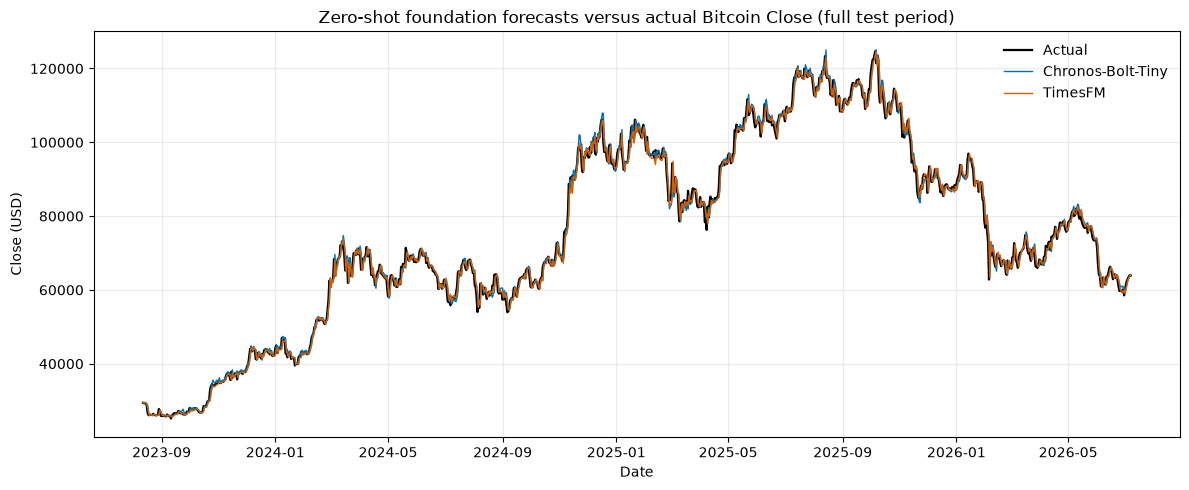

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.6, label='Actual')
ax.plot(validated.index, validated.Chronos_Bolt_Tiny, color='#0072B2', linewidth=1.0, label='Chronos-Bolt-Tiny')
ax.plot(validated.index, validated.TimesFM, color='#D55E00', linewidth=1.0, label='TimesFM')
ax.set(title='Zero-shot foundation forecasts versus actual Bitcoin Close (full test period)', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Both trajectories track the broad price path reasonably closely at this scale, with no visible systematic offset from Actual across the whole series. The two forecasts visibly diverge from each other more noticeably during the sharper local moves later in the test window than during the calmer stretches earlier on, where they largely overlap. This is consistent with the residual and volatility-conditioned evidence in Section 6, but nothing about causality is claimed from the plot alone.

# 5. Uncertainty and Calibration

`bitcoin_uncertainty_evidence_v2.csv` and `foundation_uncertainty_summary.csv` separate native model output from a training-only conformal (CQR) adjustment. The calibration window is a 180-day training-only holdout (2023-02-13 to 2023-08-11) strictly before the final test period; no test residual is used to compute the adjustment (verified from `src.bitcoin_uncertainty_calibration.generate_calibration_artifact`).

### Native intervals

Native intervals are each model's own quantile output, taken directly from the pretrained checkpoint with no post-hoc adjustment.

### Training-only calibrated intervals

Calibrated intervals apply a single scalar conformal adjustment, computed once from the training-only calibration window, to each model's native interval bounds. They are a post-hoc correction, not a native model output, and are labelled as such throughout.

In [8]:
uncertainty_summary = pd.read_csv(ROOT / 'results' / 'foundation_uncertainty_summary.csv')
uncertainty_summary[['Model', 'Native_Test_Coverage_80', 'Calibrated_Test_Coverage_80',
                     'Native_Average_Width_80', 'Calibrated_Average_Width_80']].round(4)

,Model,Native_Test_Coverage_80,Calibrated_Test_Coverage_80,Native_Average_Width_80,Calibrated_Average_Width_80
0,Chronos_Bolt_Tiny,0.8454,0.8153,5151.9599,4878.1318
1,TimesFM,0.3308,0.5561,1436.6275,2518.7603


At the nominal 80% level: Chronos's native coverage (approximately 84.5%) is already close to nominal and calibration moves it slightly closer still (approximately 81.5%). TimesFM's native coverage (approximately 33.1%) is far below nominal -- its intervals are much too narrow -- and training-only calibration widens them substantially but coverage still remains materially under nominal (approximately 55.6%). No unsupported 95% interval is computed or implied; only the 80% level actually produced by the generation code is reported.

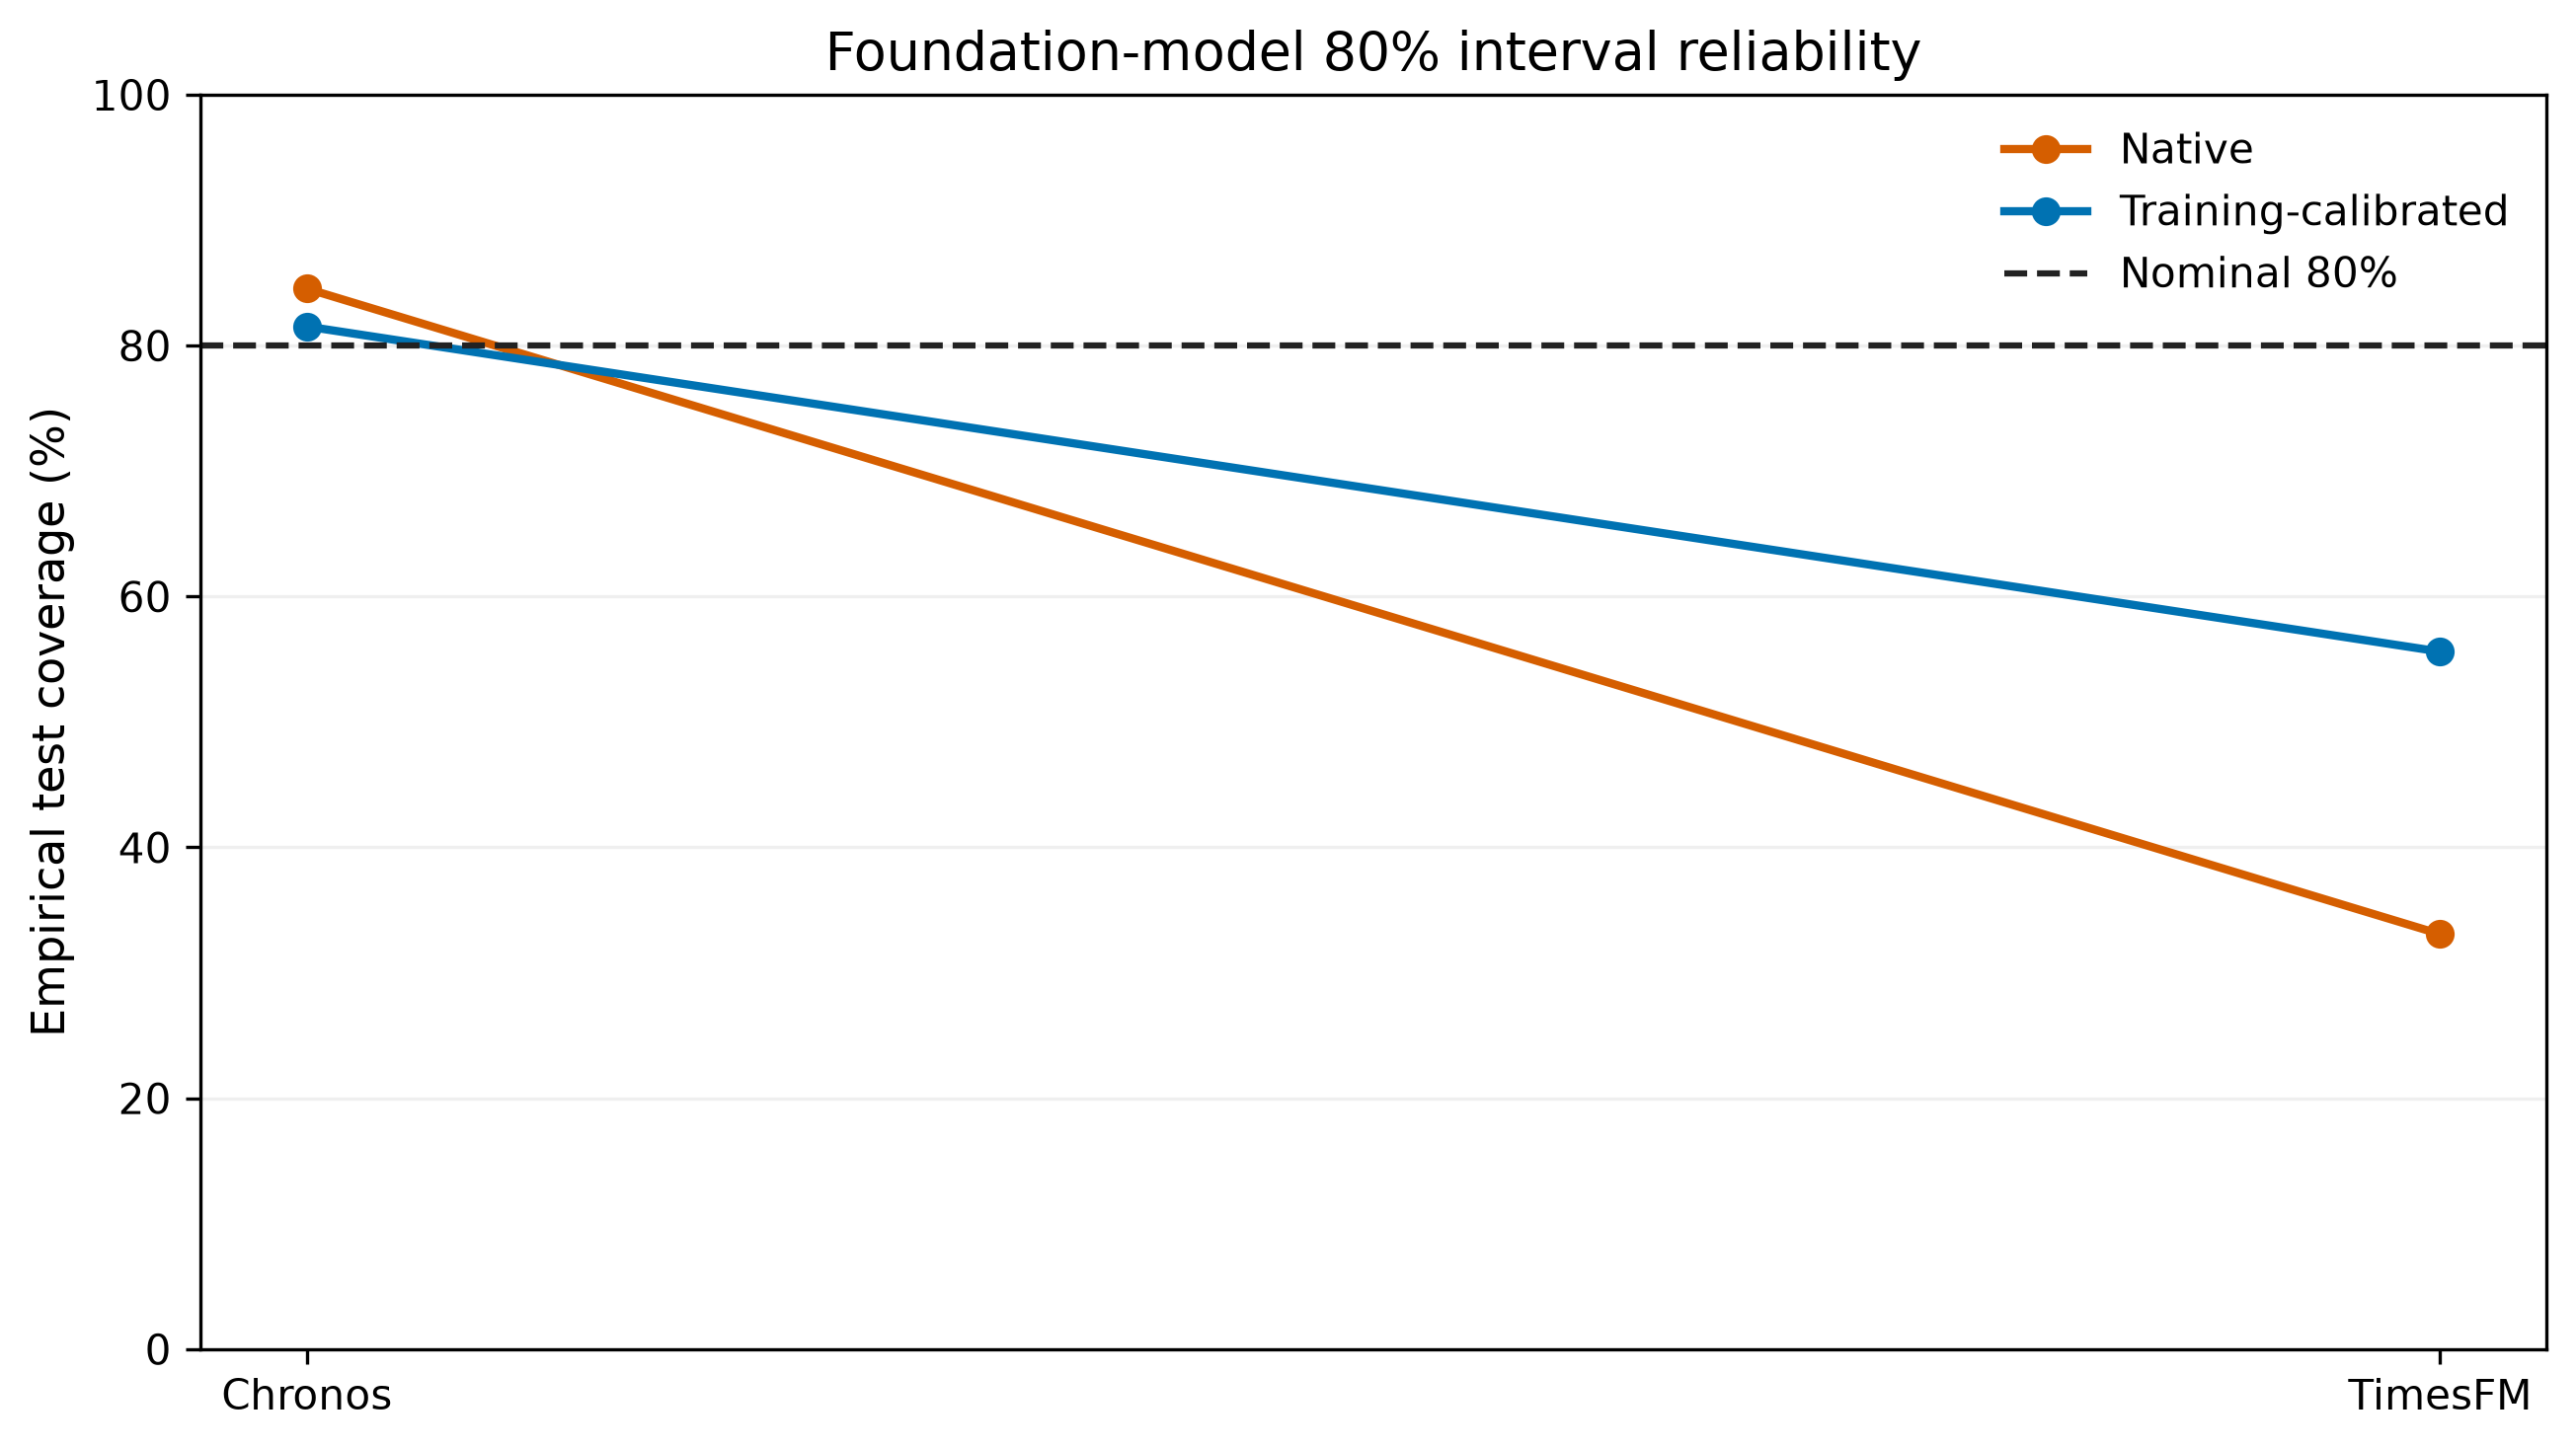

In [9]:
from IPython.display import Image, display

# Display the verified frozen-data reliability figure without recomputation.
display(Image(filename=str(ROOT / 'figures' / 'bitcoin' / 'bitcoin_uncertainty_reliability.png')))

# 6. Residual Analysis

Residuals are defined consistently as `e_t = y_t - y_hat_t` (Actual minus Forecast).

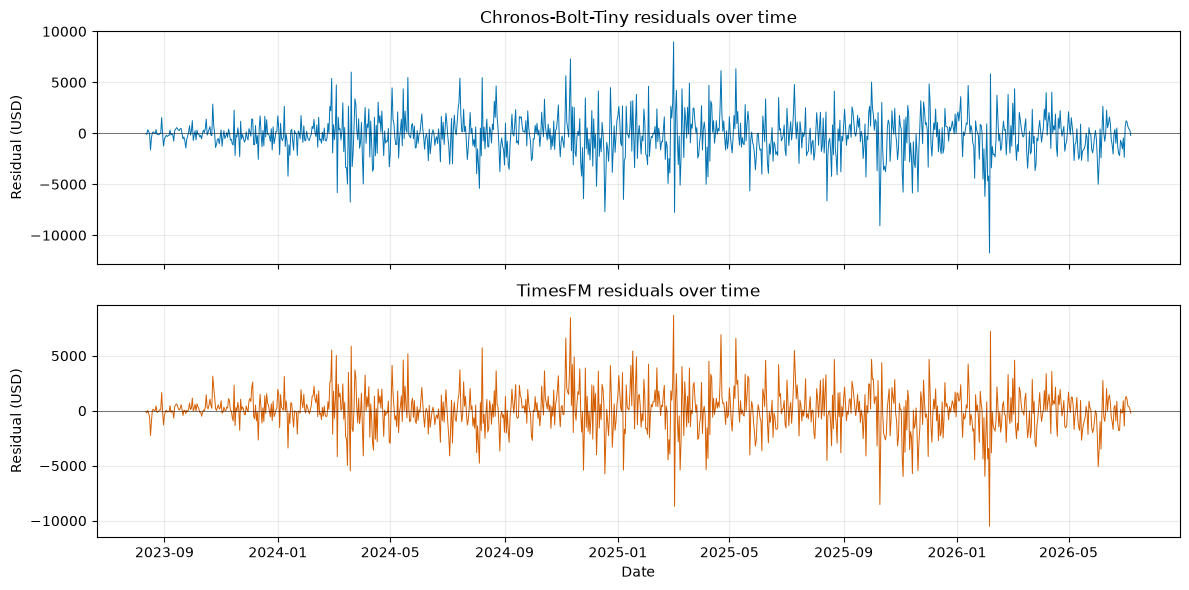

In [10]:
chronos_residual = validated.Actual - validated.Chronos_Bolt_Tiny
timesfm_residual = validated.Actual - validated.TimesFM

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(chronos_residual.index, chronos_residual, color='#0072B2', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.6, alpha=0.6)
axes[0].set(title='Chronos-Bolt-Tiny residuals over time', ylabel='Residual (USD)')
axes[1].plot(timesfm_residual.index, timesfm_residual, color='#D55E00', linewidth=0.7)
axes[1].axhline(0, color='black', linewidth=0.6, alpha=0.6)
axes[1].set(title='TimesFM residuals over time', xlabel='Date', ylabel='Residual (USD)')
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

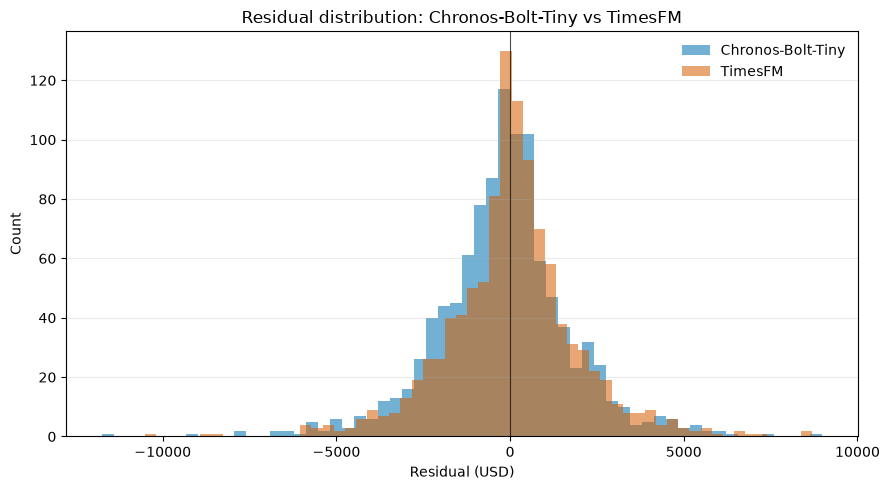

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(chronos_residual, bins=60, color='#0072B2', alpha=0.55, label='Chronos-Bolt-Tiny')
ax.hist(timesfm_residual, bins=60, color='#D55E00', alpha=0.55, label='TimesFM')
ax.axvline(0, color='black', linewidth=0.8, alpha=0.7)
ax.set(title='Residual distribution: Chronos-Bolt-Tiny vs TimesFM', xlabel='Residual (USD)', ylabel='Count')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [12]:
residual_summary = pd.DataFrame({
    'Chronos-Bolt-Tiny': {
        'Mean Residual': chronos_residual.mean(), 'Median': chronos_residual.median(),
        'Std': chronos_residual.std(), 'Min': chronos_residual.min(), 'Max': chronos_residual.max(),
        'MAE': chronos_residual.abs().mean(),
    },
    'TimesFM': {
        'Mean Residual': timesfm_residual.mean(), 'Median': timesfm_residual.median(),
        'Std': timesfm_residual.std(), 'Min': timesfm_residual.min(), 'Max': timesfm_residual.max(),
        'MAE': timesfm_residual.abs().mean(),
    },
}).T.round(3)
residual_summary

,Mean Residual,Median,Std,Min,Max,MAE
Chronos-Bolt-Tiny,-189.877,-120.141,1985.883,-11742.805,8968.516,1424.026
TimesFM,43.245,51.322,1924.621,-10515.594,8681.273,1349.947


Chronos's residual mean is negative (approximately -\$190, median approximately -\$120) -- a mild tendency to over-forecast -- while TimesFM's is close to zero and slightly positive (mean approximately +\$43, median approximately +\$51). Both have broadly similar dispersion (std approximately \$1,900-2,000) and similar extreme values in both directions, so neither model shows an extreme one-sided bias at this level of analysis.

### Volatility-context diagnostic

This reuses the existing training-defined volatility regime thresholds from `results/bitcoin_regime_thresholds_training.csv` and `src.bitcoin_pipeline.test_regime_masks` **read-only** -- no new regime threshold is defined here, and this does not replace the formal Regime-Conditional Robustness analysis owned by `09_Bitcoin_Robustness_and_Temporal_Stability.ipynb`. It only asks whether the two foundation models' absolute point-forecast errors are larger in already-defined high- versus low-volatility test days.

In [13]:
thresholds = training_regime_thresholds(train)  # training data only, identical to the frozen CSV
masks = test_regime_masks(target, test.index, thresholds)
low_volatility = masks['Low Volatility'].fillna(False)
high_volatility = masks['High Volatility'].fillna(False)

volatility_rows = []
for name, col in [('Chronos-Bolt-Tiny', 'Chronos_Bolt_Tiny'), ('TimesFM', 'TimesFM')]:
    abs_error = (validated.Actual - validated[col]).abs()
    low_mae = abs_error.loc[low_volatility.reindex(abs_error.index, fill_value=False)].mean()
    high_mae = abs_error.loc[high_volatility.reindex(abs_error.index, fill_value=False)].mean()
    volatility_rows.append({
        'Model': name,
        'Low-Volatility MAE (bottom third)': low_mae,
        'High-Volatility MAE (top third)': high_mae,
        'Relative Increase': high_mae / low_mae,
    })
pd.DataFrame(volatility_rows).set_index('Model').round(3)

,Low-Volatility MAE (bottom third),High-Volatility MAE (top third),Relative Increase
Model,,,
Chronos-Bolt-Tiny,1197.053,2255.288,1.884
TimesFM,1160.054,2198.736,1.895


For both models, absolute error in high-volatility test days is roughly 1.9x the error in low-volatility test days (Chronos approximately 1.88x, TimesFM approximately 1.90x) -- large absolute residuals do concentrate disproportionately in the already-defined high-volatility regime for both foundation models, and the two models show a very similar relative sensitivity to volatility despite their very different uncertainty-coverage behaviour in Section 5. This is exploratory evidence only, not a formal robustness test.

# 7. Reproducibility and Regeneration Capability

## 7.1 Gated Candidate Generation

`RUN_GENERATION` defaults to `False`. Each forecast uses exactly the 128 observations strictly before its forecast timestamp. Candidate CSVs are written only to `results/staging/bitcoin/<run-id>/`, never directly to an authoritative path; normal Run All skips every import, checkpoint load, inference call, and file write in the block below.

In [14]:
FOUNDATION_RUN_ID = 'SET-AN-EXPLICIT-RUN-ID'
EXPECTED_STAGED_SHA256 = {
    'Chronos_Bolt_Tiny': None,
    'TimesFM': None,
}

if RUN_GENERATION:
    if FOUNDATION_RUN_ID == 'SET-AN-EXPLICIT-RUN-ID':
        raise ValueError('Set a unique FOUNDATION_RUN_ID before generation.')
    import torch
    from chronos import BaseChronosPipeline
    import timesfm

    contexts = []
    for forecast_date in test.index:
        context = target.loc[target.index < forecast_date].tail(128).to_numpy(dtype=np.float32)
        if len(context) != 128:
            raise ValueError(f'Expected 128 strictly past observations for {forecast_date}; got {len(context)}')
        contexts.append(context)
    context_matrix = np.stack(contexts)
    assert context_matrix.shape == (1061, 128)

    chronos = BaseChronosPipeline.from_pretrained(
        'amazon/chronos-bolt-tiny', device_map='cpu', torch_dtype=torch.float32
    )
    chronos_points = []
    for start in range(0, len(context_matrix), 32):
        _, quantiles = chronos.predict_quantiles(
            torch.tensor(context_matrix[start:start + 32]),
            prediction_length=1, quantile_levels=[0.1, 0.5, 0.9],
        )
        chronos_points.extend(quantiles[:, 0, 1].detach().cpu().numpy())

    timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        'google/timesfm-2.5-200m-pytorch', torch_compile=False
    )
    timesfm_model.compile(timesfm.ForecastConfig(
        max_context=128, max_horizon=1, normalize_inputs=True, per_core_batch_size=32
    ))
    timesfm_points, _ = timesfm_model.forecast(horizon=1, inputs=list(context_matrix))
    timesfm_points = np.asarray(timesfm_points)[:, 0]

    staging_dir = ROOT / 'results' / 'staging' / 'bitcoin' / FOUNDATION_RUN_ID
    staging_dir.mkdir(parents=True, exist_ok=False)
    staged = {
        'Chronos_Bolt_Tiny': staging_dir / 'chronos_bolt_tiny_forecast.csv',
        'TimesFM': staging_dir / 'timesfm_forecast.csv',
    }
    for model_column, values in {'Chronos_Bolt_Tiny': chronos_points, 'TimesFM': timesfm_points}.items():
        candidate = pd.DataFrame({'Timestamp': test.index, model_column: np.asarray(values, dtype=float)})
        candidate.to_csv(staged[model_column], index=False)
        validate_staged_forecast(staged[model_column], model_column, test.index)
    staged

## 7.2 Gated Authoritative Promotion

`PROMOTE_TO_AUTHORITATIVE` defaults to `False` and is gated independently of generation. Before enabling it, each staged CSV must be inspected and its reviewed SHA-256 recorded in `EXPECTED_STAGED_SHA256`; the shared `promote_staged_forecast` helper then revalidates exact schema, the 1,061 timestamps/rows, finite values, and the recorded hash before replacing an authoritative file.

In [15]:
if PROMOTE_TO_AUTHORITATIVE:
    if not RUN_GENERATION:
        raise PermissionError('Promotion requires the same intentional run to have RUN_GENERATION=True.')
    authoritative = {
        'Chronos_Bolt_Tiny': ROOT / 'results' / 'chronos_bolt_tiny_forecast.csv',
        'TimesFM': ROOT / 'results' / 'timesfm_forecast.csv',
    }
    for model_column, destination in authoritative.items():
        reviewed_hash = EXPECTED_STAGED_SHA256[model_column]
        if not reviewed_hash:
            raise ValueError(f'Record the reviewed staged SHA-256 for {model_column} before promotion.')
        promote_staged_forecast(
            staged[model_column], destination, model_column, test.index,
            explicit_opt_in=True, expected_hash=reviewed_hash,
        )

## 7.3 Reproducibility Record

In [16]:
reproducibility_record = pd.DataFrame({
    'Chronos-Bolt-Tiny': [
        'amazon/chronos-bolt-tiny', f'chronos-forecasting=={_chronos_version}', 'CPU', 'float32', 128,
        'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Partial',
    ],
    'TimesFM': [
        'google/timesfm-2.5-200m-pytorch', f'timesfm=={_timesfm_version}', 'CPU (project platform record)', 'Not explicitly configured', 128,
        'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Partial',
    ],
}, index=[
    'Checkpoint', 'Package/version', 'Device', 'Numeric precision', 'Context length',
    'Zero-shot', 'Fine-tuned on Bitcoin', 'Checkpoint revision pinned', 'Exact model commit preserved',
    'Frozen forecast artifact preserved', 'Forecast SHA-256 protected', 'Candidate regeneration path preserved',
    'Safe staging enforced', 'Promotion gated', 'Full exact regeneration currently guaranteed',
])
reproducibility_record

,Chronos-Bolt-Tiny,TimesFM
Checkpoint,amazon/chronos-bolt-tiny,google/timesfm-2.5-200m-pytorch
Package/version,chronos-forecasting==2.3.1,timesfm==2.0.2
Device,CPU,CPU (project platform record)
Numeric precision,float32,Not explicitly configured
Context length,128,128
Zero-shot,Yes,Yes
Fine-tuned on Bitcoin,No,No
Checkpoint revision pinned,No,No
Exact model commit preserved,No,No
Frozen forecast artifact preserved,Yes,Yes


Both checkpoint identifiers (`amazon/chronos-bolt-tiny`, `google/timesfm-2.5-200m-pytorch`) are mutable repository/model tags -- no exact remote revision or commit hash was preserved for either at generation time (verified against `docs/bitcoin_reproducibility.md`, which states this explicitly and does not claim exact external-model regeneration). No revision hash is invented here.

> Artifact-level reproducibility is stronger than full checkpoint-regeneration reproducibility because the exact remote model revision was not preserved.

# 8. Key Findings

### Point Forecasting

- Chronos-Bolt-Tiny's MAE is approximately 10.4% higher than Naive's; TimesFM's is approximately 4.6% higher (Section 4.2) -- neither foundation model improves on persistence.
- Both remain within the same broad performance band as the classical/supervised floor rather than trailing catastrophically: TimesFM sits ahead of Chronos and close to the PE-LSTM, and both foundation models clearly beat the PE-Transformer.

### Uncertainty

- Chronos's native 80% interval (approximately 84.5% empirical coverage) is already close to nominal; TimesFM's native interval (approximately 33.1%) is far below nominal -- its intervals are much too narrow.
- Training-only calibration improves both models where evaluated: Chronos moves to approximately 81.5% (closer still to nominal) and TimesFM widens substantially to approximately 55.6%.
- TimesFM remains materially under-covered even after calibration -- narrower intervals are not, by themselves, evidence of better uncertainty quantification.

### Transfer / Complexity

Zero-shot pretrained foundation models do not automatically dominate the fitted classical and supervised systems on this Bitcoin task: both foundation models underperform Naive and the strongest classical/recurrent comparators on point accuracy, and TimesFM's much narrower native intervals materially under-cover. This finding is scoped strictly to this dataset, this protocol, and these two checkpoints -- it is not a general claim about foundation models on other tasks.

### Reproducibility

Frozen-forecast-level reproducibility is preserved (SHA-256-protected artifacts, Section 7.3), but full exact checkpoint regeneration is not guaranteed for either model, because neither `amazon/chronos-bolt-tiny` nor `google/timesfm-2.5-200m-pytorch` was pinned to an exact remote revision at generation time.

# 9. Limitations

- Evidence covers one Bitcoin asset (BTC/USD) and one frozen final test period (1,061 days, 2023-08-12 to 2026-07-07).
- Evaluation is one-step-ahead only; no longer-horizon Bitcoin claim is made here.
- A single fixed 128-observation context length is used for both models; no context-length sensitivity analysis is reported.
- Neither model is fine-tuned on Bitcoin data -- both are evaluated strictly zero-shot.
- Potential pretraining-data overlap is an unresolved benchmark-validity risk: this Bitcoin period may overlap data seen during either model's pretraining, and this cannot be ruled out from local evidence alone.
- The exact remote checkpoint revision was not preserved for either model (Section 7.3), so results describe the evaluated checkpoints/configurations at generation time, not all possible foundation-model settings or later checkpoint updates.
- Uncertainty interpretation is limited to the supported nominal 80% level; no 95% interval is computed or implied.
- Full model regeneration depends on external package and model-hub availability, which is outside this repository's control.

# 10. Next Notebook

Next: `07_Bitcoin_Forecast_Freeze_and_Validation.ipynb`

Notebook 07 consolidates the completed forecast vectors, verifies exact target alignment, validates artifact integrity, and establishes the formal freeze boundary before downstream robustness, uncertainty, statistical inference, and trustworthiness synthesis.